# 02. Colisionadores, confusores y mediadores

En la Notebook 1 formulamos una pregunta causal:

> ¿Cuál es el efecto causal de `Pclass` sobre `Survived`?

También planteamos hipótesis causales y construimos un DAG.

En esta notebook estudiaremos tres estructuras fundamentales:

- Confusores
- Mediadores
- Colisionadores

El objetivo es entender cómo estas estructuras afectan nuestra capacidad
para estimar efectos causales.




Una variable no es "confusora", "mediadora" o "colisionadora" por sus propiedades estadísticas, sino por el papel que ocupa en un DAG causal.



Recordamos el DAG construido:


```
Sex ───────→ Pclass ───────→ Survived
 │             │
 │             ↓
 └──────────→ Survived
               ↑
               │
             Fare
               ↑
               │
             Pclass
```

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
# Cargamos el dataset clásico de Titanic
df = sns.load_dataset('titanic')

In [4]:
# Preparamos variables limpias:
# - deck_known: proxy de camarote/ubicación (A, B, C suelen estar en cubiertas superiores)
df['deck_known'] = df['deck'].notna().astype(int)
df['is_female'] = (df['sex'] == 'female').astype(int)
df['is_pclass1'] = (df['pclass'] == 1).astype(int)

In [5]:
# Filtramos filas completas para una comparación justa entre modelos
df_clean = df.dropna(subset=['survived', 'pclass', 'age', 'fare']).copy()

## Veamos como está constituida cada 'Pclass' en base a 'Sex'

Pero los pasajeros de primera y tercera clase no necesariamente tienen la misma composición de Sex y Age.

In [6]:
pd.crosstab(
    df["pclass"],
    df["sex"],
    normalize="index"
)

sex,female,male
pclass,,
1,0.435185,0.564815
2,0.413043,0.586957
3,0.293279,0.706721


## 1. Confusores



### Definición formal de Confusores y Criterio Backdoor

Un **confusor** es una variable $C$ que cumple con las siguientes tres condiciones respecto a un tratamiento $X$ y un resultado $Y$:
1. $C$ está asociada con $X$ (causa $X$ o está correlacionada con $X$ por una causa común).
2. $C$ está asociada con $Y$ (causa $Y$ o está correlacionada con $Y$ por una causa común).
3. $C$ no es un intermediario en el camino causal de $X$ a $Y$ (es decir, $C$ no es causada por $X$).

El **Criterio Backdoor** es un método para identificar un conjunto de variables de ajuste $Z$ que, cuando se controlan, permiten estimar el efecto causal de $X$ sobre $Y$. Un conjunto $Z$ satisface el Criterio Backdoor si:
1. Ningún nodo en $Z$ es un descendiente de $X$.
2. $Z$ bloquea todos los caminos "backdoor" (caminos que comienzan con una flecha apuntando a $X$) entre $X$ y $Y$. Un camino está bloqueado si contiene una cadena (A → B → C) donde B está en $Z$, una bifurcación (A ← B → C) donde B está en $Z$, o un colisionador (A → B ← C) donde B y todos sus descendientes NO están en $Z$.

Estamos interesados en el camino Pclass → Survived.

Pero existe otro camino que conecta ambas variables:

Pclass ← Sex → Survived.

Este camino puede producir una asociación entre Pclass y Survived que no representa exclusivamente el efecto causal de Pclass.

## Criterio Backdoor

En nuestro ejemplo:


```
Pclass ← Sex → Survived

```

Queremos bloquear ese camino.

Una forma conceptual de hacerlo:


```
Pclass ← Sex → Survived
          X

```

```
Sex
 ↓
[Pclass] ─────→ Survived

```

La idea fundamental:

Para estimar el efecto causal de Pclass, debemos bloquear los backdoor paths relevantes.

In [7]:
df.groupby(["pclass", "sex"])["survived"].mean()

pclass  sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

```
Pclass
   ↓
Survival

pero también:

Sex
 ↓
Survival

```

y que Sex está distribuido de manera diferente entre las clases.

Importante: esto muestra patrones compatibles con nuestra hipótesis; no demuestra por sí solo que el DAG sea causalmente verdadero.

## 2. Mediador

Un **mediador** (o variable mediadora) es una variable que se encuentra en el camino causal entre una variable independiente (tratamiento) y una variable dependiente (resultado). Es decir, el tratamiento ejerce su efecto sobre el resultado *a través* del mediador.

En un diagrama causal, un mediador $M$ para el efecto de $X$ sobre $Y$ se representa como una cadena causal $X \to M \to Y$.

El mediador es importante porque ayuda a entender *cómo* o *por qué* el tratamiento afecta al resultado. Por ejemplo, en el DAG anterior `Pclass` (clase de pasajero) afecta a `Survived` (supervivencia) en parte a través de `Fare` (tarifa). Una `Pclass` más baja (primera clase) lleva a una `Fare` más alta, y una `Fare` más alta puede estar asociada con una mayor probabilidad de `Survived`.



```
Pclass ─────→ Fare ─────→ Survived

```

```
Pclass ─────────────→ Survived
   │
   ↓
 Fare
   │
   └───────────────→ Survived
```


No debemos bloquear el camino a través del mediador si queremos el efecto total.

## 3. Colisionadores

### Definición

Un **colisionador** es una variable $C$ que es causada por dos o más variables $A$ y $B$, es decir, $A \to C \leftarrow B$. Un colisionador no es inherentemente un problema en el análisis causal a menos que se ajuste por él (o por un descendiente de él).

Cuando se ajusta por un colisionador, se abre un camino "backdoor" no causal entre sus causas ($A$ y $B$) que antes estaba bloqueado. Esto puede introducir un sesgo en la estimación del efecto causal entre $A$ y $B$. Este fenómeno se conoce como **sesgo de colisionador** o **paradoxa de Berkson**.

En el contexto de nuestro DAG del Titanic, un posible colisionador podría ser `Survived`. Si `Pclass` influye en `Survived` y `Sex` también influye en `Survived`, entonces `Survived` sería un colisionador con respecto a `Pclass` y `Sex`. Si intentáramos analizar la relación entre `Pclass` y `Sex` *ajustando* por `Survived` (es decir, observando solo a los que sobrevivieron o solo a los que no), podríamos introducir una asociación espuria entre `Pclass` y `Sex` que no existía en la población general.

### DAG

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
dag = nx.DiGraph()

dag.add_edges_from([
    ("sex", "pclass"),
    ("sex", "survived"),
    ("age", "pclass"),
    ("age", "survived"),
    ("pclass", "fare"),
    ("fare", "survived"),
    ("pclass", "survived")
])

In [10]:
print(dag)

DiGraph with 5 nodes and 7 edges


## Librería DoWhy

La librería **DoWhy** es un marco de trabajo de Python para la inferencia causal. Su objetivo principal es simplificar el proceso de aplicar los principios de la inferencia causal a los datos, guiando al usuario a través de los cuatro pasos principales del análisis causal:

1.  **Modelo:** Representar el conocimiento causal del dominio mediante un grafo (como un DAG, Diagrama Acíclico Dirigido). DoWhy permite definir este modelo de varias maneras, incluyendo grafos basados en texto o objetos `networkx`.
2.  **Identificación:** Identificar un estimador para el efecto causal de interés a partir del modelo causal. Esto significa encontrar una expresión matemática que, bajo ciertas suposiciones (como el criterio backdoor), represente el efecto causal que buscamos.
3.  **Estimación:** Usar los datos para estimar el estimador identificado. DoWhy ofrece varios métodos de estimación, como ajuste de regresión, emparejamiento, ponderación por propensión, etc.
4.  **Refutación:** Probar la robustez de la estimación causal realizando pruebas de sensibilidad a suposiciones no verificables, como la existencia de confusores no observados.

DoWhy ayuda a formalizar el razonamiento causal, lo que es crucial para evitar conclusiones erróneas basadas únicamente en correlaciones. Facilita la exploración de diferentes estrategias para abordar el sesgo y proporciona herramientas para validar la robustez de los hallazgos causales.

In [11]:
!pip install dowhy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 64.7 MB/s eta 0:00:00
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,deck_known,is_female,is_pclass1
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0,0,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1,1,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,1,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1,1,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0,0,0


In [13]:
from dowhy import CausalModel

In [14]:
model = CausalModel(
    data=df,
    treatment="pclass",
    outcome="survived",
    graph=dag
)

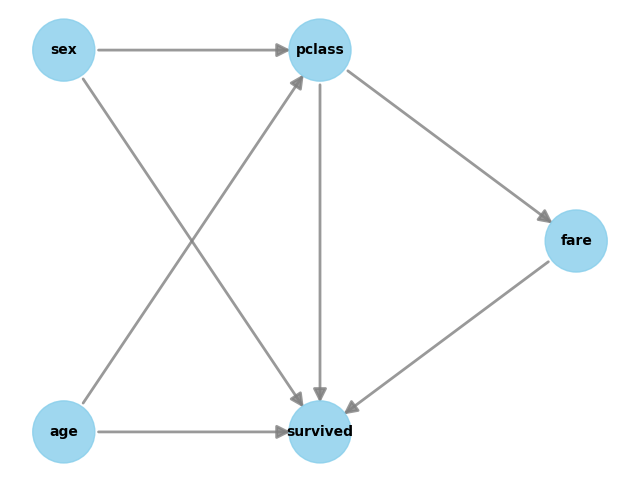

In [15]:
model.view_model()

In [16]:
identified_estimand = model.identify_effect()

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                         
─────────(E[survived|age,sex])
d[pclass]                     
Estimand assumption 1, Unconfoundedness: If U→{pclass} and U→survived then P(survived|pclass,age,sex,U) = P(survived|pclass,age,sex)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                         
─────────(E[survived|age,sex])
d[pclass]                     
Estimand assumption 1, Unconfoundedness: If U→{pclass} and U→survived then P(survived|pclass,age,sex,U) = P(survived|pclass,age,sex)



In [17]:
print("Variables a ajustar:", identified_estimand.get_backdoor_variables())

Variables a ajustar: ['age', 'sex']


Tener el DAG claro antes de modelar define qué tipo de modelo construir:

1. Si tu objetivo es la Toma de Decisiones / Intervención ($do(X)$):Usas el set de variables identificado por el DAG para estimar el efecto causal o el uplift (por ejemplo, con DoWhy, regresión con covariables de control o Causal Forests). Aquí el coeficiente o el efecto marginal es lo que importa para decidir si mover o no la palanca de negocio.

2. Si tu objetivo es solo Predicción Pasiva ($P(Y \mid X)$):El DAG te sirve para saber con certeza qué features no debes incluir jamás (evitar colisionadores que sesgan el entrenamiento o mediadores que no existirán en tiempo real cuando el modelo infiera). Tu modelo resultante será mucho más resistente al data drift.